In [2]:
"""
Round 3 Part 1: Seen region 
Pre Round top3 
    --> MOO search
        -->  zero-shot filter
            --> Activity filter
                --> ~30 mutation
"""

import json
import os
import logging
import numpy as np
import requests
from PIL import Image
import scipy.stats
import matplotlib.pyplot as plt
import sys
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

# pandas
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
from tqdm import tqdm
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)
tqdm.pandas()

# check环境
print(sys.executable)
print(sys.version)

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
/nfs_beijing/kubeflow-user/yujie/.conda/envs/icey/bin/python
3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]


In [3]:
def lib_mutation_distribution(df, title, density=True, exlist=[]):
    out = {}
    for mut in df['pdb_mutation'].to_list():
        if mut == '':
            continue
        mut = mut.split(',')

        for m in mut:
            if m in exlist:
                continue
            posi = int(m[2:-1])
            if posi not in out:
                out[posi] = {}
            if m[-1] not in out[posi]:
                out[posi][m[-1]] = 0
            out[posi][m[-1]] += 1
    # 创建热力图
    mut_df = pd.DataFrame(out).sort_index().fillna(0).T
    if density:
        mut_df = mut_df.div(mut_df.sum(axis=1), axis=0)
    mut_df = mut_df.sort_index()
    fig, ax = plt.subplots(figsize=(10, 10 * (mut_df.shape[0] / mut_df.shape[1])), dpi=200)
    im = ax.imshow(mut_df, cmap='YlOrRd')

    # 添加颜色条
    cbar = ax.figure.colorbar(im, ax=ax)
    # 添加标题和坐标轴标签
    ax.set_title(f'Distribution of mutations: {title}')
    ax.set_ylabel('Amino Acid Position')
    ax.set_xlabel('Amino Acid')

    # 设置坐标轴刻度标签
    ax.set_xticks(np.arange(len(mut_df.columns)))
    ax.set_yticks(np.arange(len(mut_df.index)))
    ax.set_xticklabels(mut_df.columns)
    ax.set_yticklabels(mut_df.index)
    # 显示图形
    plt.show()

## Read MOO Scaned

In [4]:
data = pd.read_csv('../data/data_ai_r3_all_scaned_seen_region.csv')

In [5]:
# 沿用之前的阈值，简化逻辑，避免额外的人工干预
filter_config = {
    'activity_v2': 'activity_v2 > 3.58',
    'sequence_naturalness': 'sequence_naturalness < 3.6', 
    'stability': 'stability > -0.4',
    'structure_naturalness': 'structure_naturalness > -10.32',
    
}
# 联合过滤漏斗
data_filtered = data.copy(deep=True)
for score, query in filter_config.items():
    data_filtered = data_filtered.query(query)
    print(score, query, data_filtered.shape[0], round(data_filtered.shape[0]/data.shape[0], 3))

activity_v2 activity_v2 > 3.58 150 0.046
sequence_naturalness sequence_naturalness < 3.6 150 0.046
stability stability > -0.4 150 0.046
structure_naturalness structure_naturalness > -10.32 30 0.009


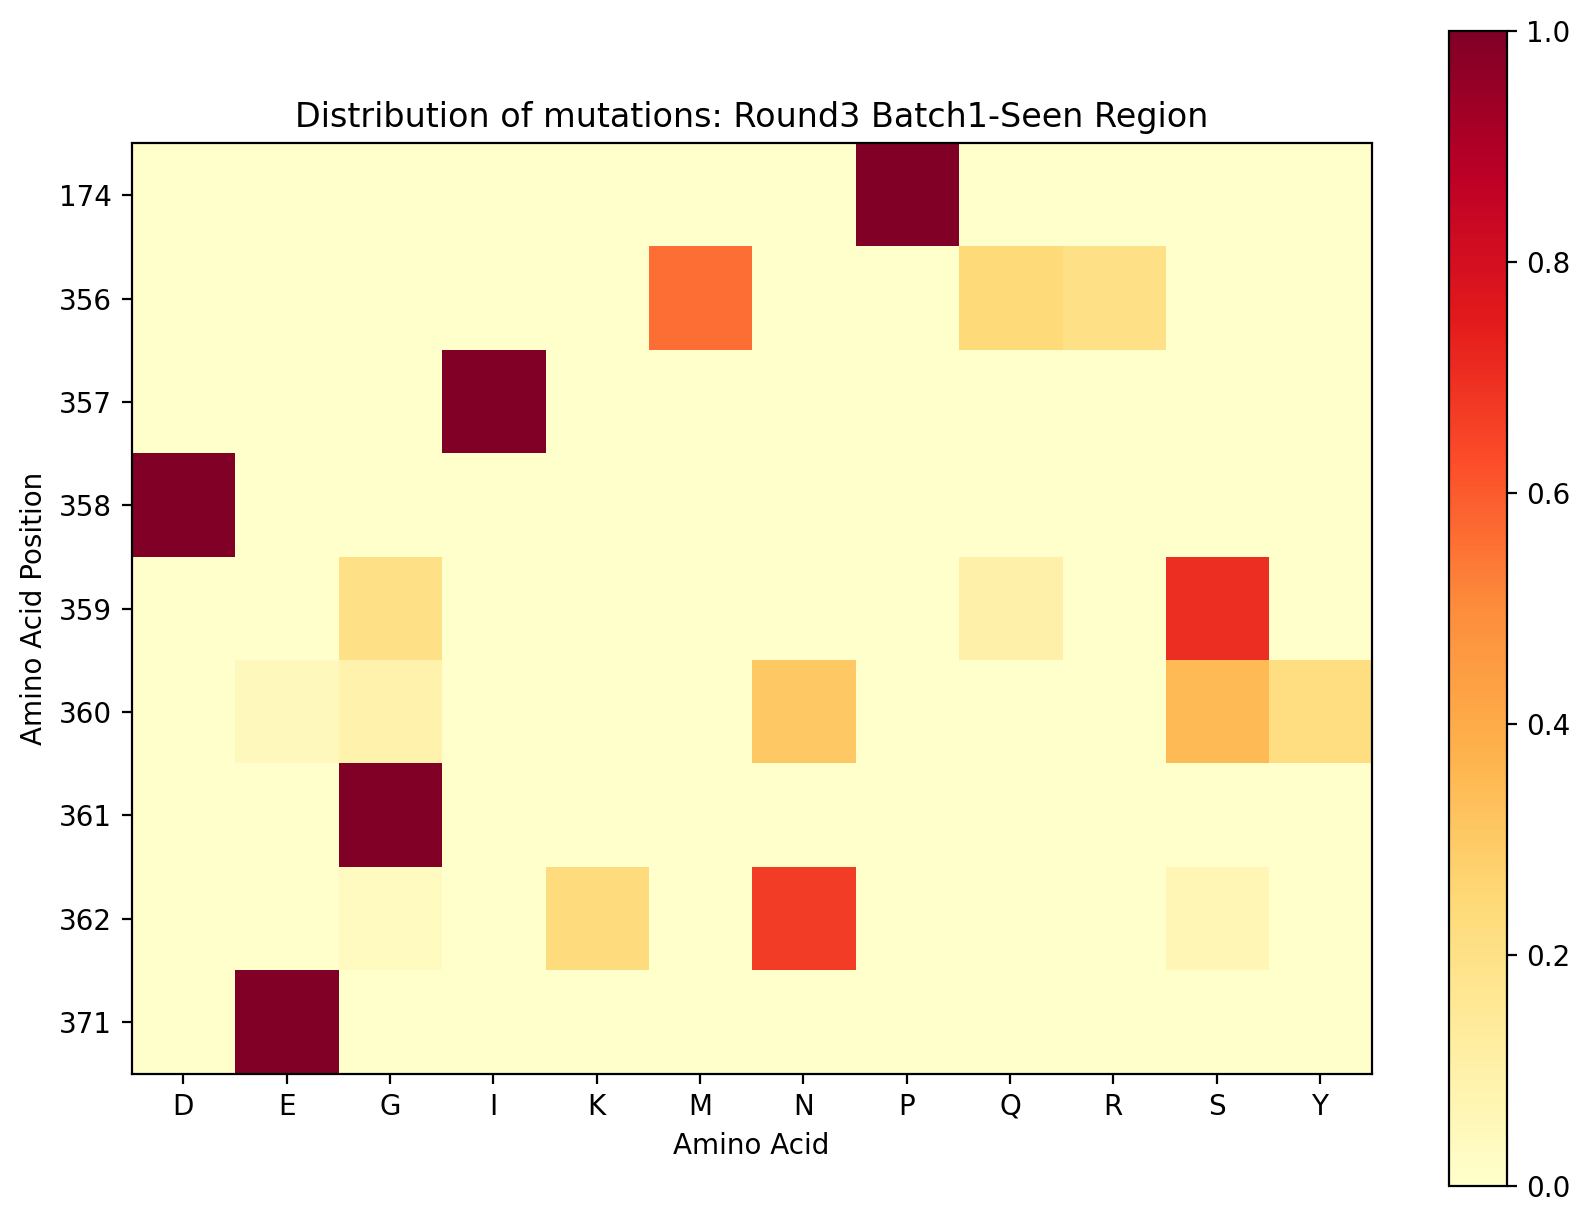

In [6]:
lib_mutation_distribution(data_filtered, title='Round3 Batch1-Seen Region')

In [7]:
data_filtered.to_csv('../data/candidates_ai_round3_batch1_seen_region.csv')